# Segmentation-Based Attention Analysis (Fast Version)

This notebook makes the qualitative experiment from Section 4.4 more quantitative by:
1. Loading pre-extracted attention patterns (fast!)
2. Visualizing images with patch grids
3. Manual annotation of counterfactual patches
4. Computing attention statistics

## ⚠️ Important: Run Preprocessing First!

Before using this notebook, extract attention patterns by running:

```bash
poetry run python 0_extract_attention.py --num_samples 20 --k_heads 20
```

This takes 5-10 minutes and only needs to be done once. Results are cached.

## Setup

In [14]:
from pathlib import Path
import json
import pickle
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 8)

print("✓ Imports loaded")

✓ Imports loaded


## Load Cached Data

In [15]:
# Load cached attention data
CACHE_DIR = Path("cache")

if not CACHE_DIR.exists():
    print("❌ Cache directory not found!")
    print("")
    print("Please run the preprocessing script first:")
    print("  poetry run python 0_extract_attention.py --num_samples 20")
    raise FileNotFoundError(f"Cache directory {CACHE_DIR} does not exist")

print("Loading cached data...")

# Load configuration
with open(CACHE_DIR / "config.json", "r") as f:
    config = json.load(f)

print(f"✓ Config loaded")
print(f"  Model: {config['model_name']}")
print(f"  Samples: {config['num_samples']}")
print(f"  Heads: {config['k_heads']}")
print(f"  Generated: {config['timestamp']}")
print(f"  Gradients extracted: {config.get('extract_gradients', False)}")

# Load attention cache
with open(CACHE_DIR / "attention_cache.pkl", "rb") as f:
    cache_data = pickle.load(f)
    attention_cache = cache_data["attention_cache"]
    pattern_keys = cache_data["pattern_keys"]

print(f"✓ Attention cache loaded ({len(pattern_keys)} heads)")

# Load gradient cache if available
gradient_cache = None
if config.get("extract_gradients", False):
    gradient_file = CACHE_DIR / "gradient_cache.pkl"
    if gradient_file.exists():
        with open(gradient_file, "rb") as f:
            gradient_cache = pickle.load(f)
        print(f"✓ Gradient cache loaded")
    else:
        print("⚠️ Gradient cache not found (config says it should exist)")
else:
    print("ℹ️ No gradient cache (not extracted during preprocessing)")

# Load random attention cache
with open("cache_random/attention_cache.pkl", "rb") as f:
    cache_data_random = pickle.load(f)
    attention_cache_random = cache_data_random["attention_cache"]
    pattern_keys_random = cache_data_random["pattern_keys"]

print(f"✓ Random attention cache loaded ({len(pattern_keys_random)} heads)")

# Load random gradient cache if available
gradient_cache_random = None
random_config_file = Path("cache_random/config.json")
if random_config_file.exists():
    with open(random_config_file, "r") as f:
        random_config = json.load(f)
    if random_config.get("extract_gradients", False):
        gradient_file_random = Path("cache_random/gradient_cache.pkl")
        if gradient_file_random.exists():
            with open(gradient_file_random, "rb") as f:
                gradient_cache_random = pickle.load(f)
            print(f"✓ Random gradient cache loaded")

# Load manager data
with open(CACHE_DIR / "manager_data.pkl", "rb") as f:
    manager_data = pickle.load(f)
    map_filtered_to_original_index = manager_data["map_filtered_to_original_index"]

print(f"✓ Manager data loaded")

# Load dataloader samples
with open(CACHE_DIR / "dataloader_samples.pkl", "rb") as f:
    dataloader_samples = pickle.load(f)

print(f"✓ Dataloader samples loaded ({len(dataloader_samples)} images)")

# Extract configuration values
NUM_SAMPLES = config["num_samples"]
VISION_INPUT_SIZE = config["vision_input_size"]
PATCH_SIZE = config["patch_size"]
NUM_PATCHES = config["num_patches"]
cfact_heads = config["cfact_heads"]

print("")
print("=" * 60)
print("✓ ALL DATA LOADED SUCCESSFULLY")
print("=" * 60)
print(
    f"Ready to analyze {NUM_SAMPLES} samples with {len(pattern_keys)} counterfactual heads"
)
if gradient_cache is not None:
    print(f"Gradient saliency maps available for analysis")

Loading cached data...
✓ Config loaded
  Model: google/gemma-3-12b-it
  Samples: 433
  Heads: 20
  Generated: 2025-11-20T16:13:46.037773
  Gradients extracted: True
✓ Attention cache loaded (20 heads)
✓ Attention cache loaded (20 heads)
✓ Gradient cache loaded
✓ Gradient cache loaded
✓ Random attention cache loaded (20 heads)
✓ Manager data loaded
✓ Random attention cache loaded (20 heads)
✓ Manager data loaded
✓ Dataloader samples loaded (433 images)

✓ ALL DATA LOADED SUCCESSFULLY
Ready to analyze 433 samples with 20 counterfactual heads
Gradient saliency maps available for analysis
✓ Dataloader samples loaded (433 images)

✓ ALL DATA LOADED SUCCESSFULLY
Ready to analyze 433 samples with 20 counterfactual heads
Gradient saliency maps available for analysis


In [16]:
gradient_cache["input_embeddings_gradients"][1].shape

torch.Size([1, 256, 3840])

In [17]:
index_image = gradient_cache["mapping_index"]["all-image"]
aux = [
    torch.norm(gradient_cache["input_embeddings_gradients"][i], dim=-1)
    for i in range(len(gradient_cache["input_embeddings_gradients"]))
]
gradient_cache["input_embeddings_gradients"] = aux

In [18]:
def detect_non_white_patches(image, patch_size=16, image_size=256, white_threshold=250):
    """
    Detect patches that contain non-white pixels.

    Args:
        image: PIL Image or numpy array [H, W, 3] or torch tensor [C, H, W]
        patch_size: Size of each patch (default 14 for Gemma3)
        image_size: Target image size (default 256 for Gemma3)
        white_threshold: RGB values above this are considered white (default 250)

    Returns:
        torch.Tensor of shape [num_patches] with 1 for non-white patches, 0 for white
    """
    import torch
    import numpy as np
    from PIL import Image

    # Convert to numpy array if needed
    if isinstance(image, Image.Image):
        image_np = np.array(image)
    elif isinstance(image, torch.Tensor):
        if image.ndim == 3 and image.shape[0] == 3:  # [C, H, W]
            image_np = image.permute(1, 2, 0).cpu().numpy()
        else:
            image_np = image.cpu().numpy()
    else:
        image_np = image

    # Ensure uint8
    if image_np.dtype != np.uint8:
        if image_np.max() <= 1.0:  # Normalized to [0, 1]
            image_np = (image_np * 255).astype(np.uint8)
        else:
            image_np = image_np.astype(np.uint8)

    # Resize to target size if needed
    if image_np.shape[0] != image_size or image_np.shape[1] != image_size:
        pil_img = Image.fromarray(image_np)
        pil_img = pil_img.resize((image_size, image_size), Image.Resampling.BILINEAR)
        image_np = np.array(pil_img)

    # Calculate number of patches per side
    num_patches_per_side = image_size // patch_size
    num_patches = num_patches_per_side**2

    # Initialize result tensor
    non_white_mask = torch.zeros(num_patches, dtype=torch.float32)

    # Process each patch
    for i in range(num_patches_per_side):
        for j in range(num_patches_per_side):
            # Extract patch with bounds checking
            row_start = i * patch_size
            col_start = j * patch_size
            row_end = min((i + 1) * patch_size, image_size)
            col_end = min((j + 1) * patch_size, image_size)

            patch = image_np[row_start:row_end, col_start:col_end]

            # Check if pixel is white (all RGB channels > threshold)
            is_white = (
                (patch[:, :, 0] > white_threshold)
                & (patch[:, :, 1] > white_threshold)
                & (patch[:, :, 2] > white_threshold)
            )

            # Count non-white pixels in this patch
            num_non_white = (~is_white).sum()
            total_pixels = patch.shape[0] * patch.shape[1]  # ← Use actual patch size

            # If majority of pixels are non-white, mark patch as 1
            patch_idx = i * num_patches_per_side + j
            if num_non_white > (total_pixels / 2):
                non_white_mask[patch_idx] = 1.0

    return non_white_mask

## Gradient Analysis Functions

If gradients were extracted during preprocessing, we can analyze gradient saliency maps.

**Key insight**: Gradients are computed w.r.t. the **counterfactual token** logit, so:
- High gradient magnitude = patches that causally influence the wrong answer
- These patches are "pushing" the model toward the counterfactual prediction

This is complementary to attention patterns:
- **Attention**: Where the model looks
- **Gradients**: What causally affects the output

In [19]:
sample_image = {  # name, original_index
    "pirate": 457,
    "zuck": 463,
    "liberty": 12,
    "lennon": 13,
    "liberty2": 63,
    "child_newspaper": 95,
    "zebra": 100,
    "iena": 119,
    "boat": 130,
    "lighthouse": 215,
    "childfire": 216,
    "train": 350,
    "hat": 409,
    "fruit": 2,
    "mask": 26,
    "macbook": 39,
    "fire": 49,
    "sand": 70,
    "penguin": 73,
    "pizza": 99,
    # "bill_gates": 157,
}

In [32]:
def average_attention(original_index, attention_cache):
    map_original_to_filtered_index = {
        v: k for k, v in map_filtered_to_original_index.items()
    }
    filtered_index = map_original_to_filtered_index[original_index]

    # check filtered_index is valid
    if filtered_index is None:
        raise ValueError(
            f"Original index {original_index} not found in filtered indices"
        )

    attention_only_index = {}
    for key in attention_cache.keys():
        if key.startswith("pattern_"):
            # print(f"Processing key: {key}")
            attention_only_index[key] = attention_cache[key][filtered_index]

    average_attention = torch.zeros_like(
        attention_only_index[next(iter(attention_only_index))]
    )
    for key in attention_only_index.keys():
        average_attention += attention_only_index[key]
    average_attention /= len(attention_only_index)

    return average_attention, attention_only_index


def get_gradient_saliency(original_index, gradient_cache):
    """
    Extract gradient saliency for a specific image.

    Gradients are w.r.t. counterfactual token logit, so they show which
    patches would increase the wrong answer probability.

    Returns:
        gradient_magnitude: [1, 1, num_image_patches] tensor of gradient magnitudes
    """
    if gradient_cache is None:
        return None

    map_original_to_filtered_index = {
        v: k for k, v in map_filtered_to_original_index.items()
    }
    filtered_index = map_original_to_filtered_index[original_index]

    if filtered_index is None:
        raise ValueError(
            f"Original index {original_index} not found in filtered indices"
        )

    # Get gradients for this sample
    gradients = gradient_cache["input_embeddings_gradients"][filtered_index]

    # Check if gradients have already been processed (L2 norm applied in cell 7)
    # After cell 7: shape is [1, num_patches] or [num_patches]
    # Before cell 7: shape is [1, num_patches, embed_dim] or similar

    if gradients.ndim == 1:
        # Shape: [num_patches] - already processed, just add dimensions
        gradient_magnitude = gradients.unsqueeze(0).unsqueeze(0)
    elif gradients.ndim == 2:
        # Could be [1, num_patches] (processed) or [num_patches, embed_dim] (not processed)
        # Check the second dimension to determine
        if gradients.shape[1] > 1000:  # embed_dim is usually > 1000
            # Not processed: [num_patches, embed_dim] or [1, embed_dim*patches]
            gradient_magnitude = torch.norm(gradients, dim=-1, keepdim=False)
            if gradient_magnitude.ndim == 0:
                gradient_magnitude = (
                    gradient_magnitude.unsqueeze(0).unsqueeze(0).unsqueeze(0)
                )
            elif gradient_magnitude.ndim == 1:
                gradient_magnitude = gradient_magnitude.unsqueeze(0).unsqueeze(0)
        else:
            # Already processed: [1, num_patches]
            # Just add one more dimension to make [1, 1, num_patches]
            gradient_magnitude = gradients.unsqueeze(1)
    elif gradients.ndim == 3:
        # Shape: [1, num_patches, embed_dim] - not processed
        gradient_magnitude = torch.norm(gradients, dim=-1, keepdim=False)
        if gradient_magnitude.ndim == 2:
            gradient_magnitude = gradient_magnitude.unsqueeze(1)
    else:
        raise ValueError(f"Unexpected gradient shape: {gradients.shape}")

    return gradient_magnitude


In [21]:
zuck_avg = average_attention(12, attention_cache)[0]

In [22]:
zuck_avg.shape


torch.Size([1, 1, 256])

In [23]:
import torch


def percentage_on_the_mask_with_density(avg_tensor, mask, eps=1e-12):
    """
    avg_tensor: tensor of attention scores, shape (..., seq_len)
    mask: tensor of shape (seq_len,) or (..., seq_len) with 0/1 or bools

    Returns:
        pct_on_mask: percentage of attention on masked positions
        total_attention
        attention_on_mask
        attention_outside_mask
        concentration_ratio:
            (pct_on_mask) / (expected_pct_if_attention_was_uniform_over_tokens)
            > 1 means attention is denser on the masked positions than uniform
        avg_ratio: (avg attention on mask) / (avg attention on all patches)
    """

    # Ensure mask is boolean, based on 0/1 or probabilities
    if mask.dtype != torch.bool:
        mask_bool = mask > 0.5
    else:
        mask_bool = mask

    mask_bool = mask_bool.to(avg_tensor.device)

    # Cast to float for multiplication
    mask_float = mask_bool.to(dtype=avg_tensor.dtype)

    # Attention on mask vs outside
    attention_on_mask = (avg_tensor * mask_float).sum(dim=-1)
    attention_outside_mask = (avg_tensor * (1.0 - mask_float)).sum(dim=-1)
    total_attention = attention_on_mask + attention_outside_mask

    # Percentage of attention on mask
    pct_on_mask = attention_on_mask / (total_attention + eps) * 100.0

    # How many positions are masked, and total positions
    seq_len = avg_tensor.size(-1)
    # If mask is broadcastable, reduce along last dim
    masked_positions = mask_bool.to(dtype=avg_tensor.dtype).sum(dim=-1)
    total_positions = float(seq_len)

    # Expected percentage on mask if attention were perfectly uniform
    expected_pct_uniform = (masked_positions / (total_positions + eps)) * 100.0

    # Concentration ratio: how much denser than uniform the attention is
    concentration_ratio = pct_on_mask / (expected_pct_uniform + eps)

    # NEW: Compute average-based ratio
    # Average attention on masked patches
    avg_on_mask = attention_on_mask / (masked_positions + eps)
    # Average attention on all patches
    avg_on_all = total_attention / (total_positions + eps)
    # Ratio of averages
    avg_ratio = avg_on_mask / (avg_on_all + eps)

    return (
        pct_on_mask,
        total_attention,
        attention_on_mask,
        attention_outside_mask,
        concentration_ratio,
        avg_ratio,
    )


In [24]:
def measure_single_image(image_name: str):
    if image_name not in sample_image:
        raise ValueError(f"Image name {image_name} not found in sample_image dict")
    original_index = sample_image[image_name]

    # Load segmented image
    possible_filenames = [
        f"data_whoops_segmented/{image_name}_sem.jpg",
        f"data_whoops_segmented/{image_name}_sem.png",
    ]
    image = None
    for filename in possible_filenames:
        try:
            image = Image.open(filename).convert("RGB")
            break
        except FileNotFoundError:
            continue
    if image is None:
        raise FileNotFoundError(f"Segmented image file for {image_name} not found")

    mask = detect_non_white_patches(image)

    # Attention analysis
    avg_attention, attention_per_head = average_attention(
        original_index, attention_cache
    )
    avg_attention_random, attention_per_head_random = average_attention(
        original_index, attention_cache_random
    )

    (
        pct_on_mask,
        total_attention,
        attention_on_mask,
        attention_outside_mask,
        concentration_ratio,
        avg_ratio,
    ) = percentage_on_the_mask_with_density(avg_attention, mask.bool())
    (
        pct_on_mask_random,
        total_attention_random,
        attention_on_mask_random,
        attention_outside_mask_random,
        concentration_ratio_random,
        avg_ratio_random,
    ) = percentage_on_the_mask_with_density(avg_attention_random, mask.bool())

    result = {
        "image_name": image_name,
        "pct_on_mask": pct_on_mask.item(),
        "total_attention": total_attention.item(),
        "attention_on_mask": attention_on_mask.item(),
        "attention_outside_mask": attention_outside_mask.item(),
        "concentration_ratio": concentration_ratio.item(),
        "avg_ratio": avg_ratio.item(),
        "pct_on_mask_random": pct_on_mask_random.item(),
        "total_attention_random": total_attention_random.item(),
        "attention_on_mask_random": attention_on_mask_random.item(),
        "attention_outside_mask_random": attention_outside_mask_random.item(),
        "concentration_ratio_random": concentration_ratio_random.item(),
        "avg_ratio_random": avg_ratio_random.item(),
    }

    # Gradient analysis (if available)
    if gradient_cache is not None:
        gradient_saliency = get_gradient_saliency(original_index, gradient_cache)
        (
            pct_grad_on_mask,
            total_grad,
            grad_on_mask,
            grad_outside_mask,
            grad_concentration,
            grad_avg_ratio,
        ) = percentage_on_the_mask_with_density(gradient_saliency, mask.bool())

        result.update(
            {
                "pct_grad_on_mask": pct_grad_on_mask.item(),
                "total_gradient": total_grad.item(),
                "gradient_on_mask": grad_on_mask.item(),
                "gradient_outside_mask": grad_outside_mask.item(),
                "gradient_concentration_ratio": grad_concentration.item(),
                "gradient_avg_ratio": grad_avg_ratio.item(),
            }
        )

        if gradient_cache_random is not None:
            gradient_saliency_random = get_gradient_saliency(
                original_index, gradient_cache_random
            )
            (
                pct_grad_on_mask_rand,
                total_grad_rand,
                grad_on_mask_rand,
                grad_outside_mask_rand,
                grad_concentration_rand,
                grad_avg_ratio_rand,
            ) = percentage_on_the_mask_with_density(
                gradient_saliency_random, mask.bool()
            )

            result.update(
                {
                    "pct_grad_on_mask_random": pct_grad_on_mask_rand.item(),
                    "total_gradient_random": total_grad_rand.item(),
                    "gradient_on_mask_random": grad_on_mask_rand.item(),
                    "gradient_outside_mask_random": grad_outside_mask_rand.item(),
                    "gradient_concentration_ratio_random": grad_concentration_rand.item(),
                    "gradient_avg_ratio_random": grad_avg_ratio_rand.item(),
                }
            )

    return result

In [25]:
def get_avg_measure(std=True):
    all_pct_on_mask = []
    all_pct_on_mask_random = []
    all_concentration_ratio = []
    all_concentration_ratio_random = []
    all_avg_ratio = []
    all_avg_ratio_random = []

    # Gradient metrics
    all_pct_grad_on_mask = []
    all_pct_grad_on_mask_random = []
    all_grad_concentration_ratio = []
    all_grad_concentration_ratio_random = []
    all_grad_avg_ratio = []
    all_grad_avg_ratio_random = []

    for image_name in sample_image.keys():
        result = measure_single_image(image_name)

        # Attention metrics
        all_pct_on_mask.append(result["pct_on_mask"])
        all_pct_on_mask_random.append(result["pct_on_mask_random"])
        all_concentration_ratio.append(result["concentration_ratio"])
        all_concentration_ratio_random.append(result["concentration_ratio_random"])
        all_avg_ratio.append(result["avg_ratio"])
        all_avg_ratio_random.append(result["avg_ratio_random"])

        # Gradient metrics (if available)
        if "pct_grad_on_mask" in result:
            all_pct_grad_on_mask.append(result["pct_grad_on_mask"])
            all_grad_concentration_ratio.append(result["gradient_concentration_ratio"])
            all_grad_avg_ratio.append(result["gradient_avg_ratio"])

            if "pct_grad_on_mask_random" in result:
                all_pct_grad_on_mask_random.append(result["pct_grad_on_mask_random"])
                all_grad_concentration_ratio_random.append(
                    result["gradient_concentration_ratio_random"]
                )
                all_grad_avg_ratio_random.append(result["gradient_avg_ratio_random"])

    # Determine number of subplots
    num_plots = 3 if not all_pct_grad_on_mask else 6

    # Plot distributions
    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(18, 6) if num_plots == 3 else (18, 12))

    # Attention plots
    plt.subplot(2, 3, 1)
    plt.hist(all_pct_on_mask, bins=10, alpha=0.7, label="Counterfactual Heads")
    plt.hist(all_pct_on_mask_random, bins=10, alpha=0.7, label="Random Heads")
    plt.title("Attention: % on Segmented Patch")
    plt.xlabel("Percentage of Attention on Mask (%)")
    plt.ylabel("Frequency")
    plt.legend()

    plt.subplot(2, 3, 2)
    plt.hist(all_concentration_ratio, bins=10, alpha=0.7, label="Counterfactual Heads")
    plt.hist(all_concentration_ratio_random, bins=10, alpha=0.7, label="Random Heads")
    plt.title("Attention: Concentration Ratio")
    plt.xlabel("Concentration Ratio")
    plt.ylabel("Frequency")
    plt.legend()

    plt.subplot(2, 3, 3)
    plt.hist(all_avg_ratio, bins=10, alpha=0.7, label="Counterfactual Heads")
    plt.hist(all_avg_ratio_random, bins=10, alpha=0.7, label="Random Heads")
    plt.title("Attention: Average Ratio")
    plt.xlabel("(Avg on Mask) / (Avg on All)")
    plt.ylabel("Frequency")
    plt.legend()

    # Gradient plots (if available)
    if all_pct_grad_on_mask:
        plt.subplot(2, 3, 4)
        if all_pct_grad_on_mask_random:
            plt.hist(
                all_pct_grad_on_mask, bins=10, alpha=0.7, label="Counterfactual Heads"
            )
            plt.hist(
                all_pct_grad_on_mask_random, bins=10, alpha=0.7, label="Random Heads"
            )
        else:
            plt.hist(
                all_pct_grad_on_mask, bins=10, alpha=0.7, label="Counterfactual Heads"
            )
        plt.title("Gradient: % on Segmented Patch")
        plt.xlabel("Percentage of Gradient on Mask (%)")
        plt.ylabel("Frequency")
        plt.legend()

        plt.subplot(2, 3, 5)
        if all_grad_concentration_ratio_random:
            plt.hist(
                all_grad_concentration_ratio,
                bins=10,
                alpha=0.7,
                label="Counterfactual Heads",
            )
            plt.hist(
                all_grad_concentration_ratio_random,
                bins=10,
                alpha=0.7,
                label="Random Heads",
            )
        else:
            plt.hist(
                all_grad_concentration_ratio,
                bins=10,
                alpha=0.7,
                label="Counterfactual Heads",
            )
        plt.title("Gradient: Concentration Ratio")
        plt.xlabel("Concentration Ratio")
        plt.ylabel("Frequency")
        plt.legend()

        plt.subplot(2, 3, 6)
        if all_grad_avg_ratio_random:
            plt.hist(
                all_grad_avg_ratio,
                bins=10,
                alpha=0.7,
                label="Counterfactual Heads",
            )
            plt.hist(
                all_grad_avg_ratio_random,
                bins=10,
                alpha=0.7,
                label="Random Heads",
            )
        else:
            plt.hist(
                all_grad_avg_ratio,
                bins=10,
                alpha=0.7,
                label="Counterfactual Heads",
            )
        plt.title("Gradient: Average Ratio")
        plt.xlabel("(Avg on Mask) / (Avg on All)")
        plt.ylabel("Frequency")
        plt.legend()

    plt.tight_layout()
    plt.show()

    # Statistical tests - Attention
    from scipy.stats import mannwhitneyu

    u_stat_pct, p_value_pct = mannwhitneyu(
        all_pct_on_mask, all_pct_on_mask_random, alternative="two-sided"
    )
    u_stat_conc, p_value_conc = mannwhitneyu(
        all_concentration_ratio, all_concentration_ratio_random, alternative="two-sided"
    )
    u_stat_avg, p_value_avg = mannwhitneyu(
        all_avg_ratio, all_avg_ratio_random, alternative="two-sided"
    )

    print("=" * 70)
    print("ATTENTION ANALYSIS")
    print("=" * 70)
    print(f"Mann-Whitney U Test Results:")
    print(
        f"  Percentage on Mask: U-statistic = {u_stat_pct}, p-value = {p_value_pct:.4e}"
    )
    print(
        f"  Concentration Ratio: U-statistic = {u_stat_conc}, p-value = {p_value_conc:.4e}"
    )
    print(f"  Average Ratio: U-statistic = {u_stat_avg}, p-value = {p_value_avg:.4e}")
    print()

    if std:
        # Standard deviation mode
        avg_pct_on_mask_mean = np.mean(all_pct_on_mask)
        avg_pct_on_mask_random_mean = np.mean(all_pct_on_mask_random)
        avg_concentration_ratio_mean = np.mean(all_concentration_ratio)
        avg_concentration_ratio_random_mean = np.mean(all_concentration_ratio_random)
        avg_ratio_mean = np.mean(all_avg_ratio)
        avg_ratio_random_mean = np.mean(all_avg_ratio_random)

        avg_pct_on_mask_std = np.std(all_pct_on_mask)
        avg_pct_on_mask_random_std = np.std(all_pct_on_mask_random)
        avg_concentration_ratio_std = np.std(all_concentration_ratio)
        avg_concentration_ratio_random_std = np.std(all_concentration_ratio_random)
        avg_ratio_std = np.std(all_avg_ratio)
        avg_ratio_random_std = np.std(all_avg_ratio_random)

        print(
            f"Average Percentage of Attention on Segmented Patch (n={len(all_pct_on_mask)}):"
        )
        print(
            f"  Counterfactual Heads: {avg_pct_on_mask_mean:.2f}% ± {avg_pct_on_mask_std:.2f}%"
        )
        print(
            f"  Random Heads: {avg_pct_on_mask_random_mean:.2f}% ± {avg_pct_on_mask_random_std:.2f}%"
        )
        print("Average Concentration Ratio:")
        print(
            f"  Counterfactual Heads: {avg_concentration_ratio_mean:.2f} ± {avg_concentration_ratio_std:.2f}"
        )
        print(
            f"  Random Heads: {avg_concentration_ratio_random_mean:.2f} ± {avg_concentration_ratio_random_std:.2f}"
        )
        print("Average Ratio (Avg on Mask / Avg on All):")
        print(f"  Counterfactual Heads: {avg_ratio_mean:.2f} ± {avg_ratio_std:.2f}")
        print(
            f"  Random Heads: {avg_ratio_random_mean:.2f} ± {avg_ratio_random_std:.2f}"
        )
    else:
        # Quartile mode
        pct_on_mask_q1, pct_on_mask_median, pct_on_mask_q3 = np.percentile(
            all_pct_on_mask, [25, 50, 75]
        )
        pct_on_mask_random_q1, pct_on_mask_random_median, pct_on_mask_random_q3 = (
            np.percentile(all_pct_on_mask_random, [25, 50, 75])
        )
        concentration_ratio_q1, concentration_ratio_median, concentration_ratio_q3 = (
            np.percentile(all_concentration_ratio, [25, 50, 75])
        )
        (
            concentration_ratio_random_q1,
            concentration_ratio_random_median,
            concentration_ratio_random_q3,
        ) = np.percentile(all_concentration_ratio_random, [25, 50, 75])
        avg_ratio_q1, avg_ratio_median, avg_ratio_q3 = np.percentile(
            all_avg_ratio, [25, 50, 75]
        )
        avg_ratio_random_q1, avg_ratio_random_median, avg_ratio_random_q3 = (
            np.percentile(all_avg_ratio_random, [25, 50, 75])
        )

        print(f"Percentage of Attention on Segmented Patch (n={len(all_pct_on_mask)}):")
        print(
            f"  Counterfactual Heads: median {pct_on_mask_median:.2f}% "
            f"(Q1 {pct_on_mask_q1:.2f}%, Q3 {pct_on_mask_q3:.2f}%)"
        )
        print(
            f"  Random Heads: median {pct_on_mask_random_median:.2f}% "
            f"(Q1 {pct_on_mask_random_q1:.2f}%, Q3 {pct_on_mask_random_q3:.2f}%)"
        )
        print("Concentration Ratio:")
        print(
            f"  Counterfactual Heads: median {concentration_ratio_median:.2f} "
            f"(Q1 {concentration_ratio_q1:.2f}, Q3 {concentration_ratio_q3:.2f})"
        )
        print(
            f"  Random Heads: median {concentration_ratio_random_median:.2f} "
            f"(Q1 {concentration_ratio_random_q1:.2f}, Q3 {concentration_ratio_random_q3:.2f})"
        )
        print("Average Ratio (Avg on Mask / Avg on All):")
        print(
            f"  Counterfactual Heads: median {avg_ratio_median:.2f} "
            f"(Q1 {avg_ratio_q1:.2f}, Q3 {avg_ratio_q3:.2f})"
        )
        print(
            f"  Random Heads: median {avg_ratio_random_median:.2f} "
            f"(Q1 {avg_ratio_random_q1:.2f}, Q3 {avg_ratio_random_q3:.2f})"
        )

    # Gradient analysis (if available)
    if all_pct_grad_on_mask:
        print()
        print("=" * 70)
        print("GRADIENT ANALYSIS (w.r.t. Counterfactual Token)")
        print("=" * 70)

        if all_pct_grad_on_mask_random:
            u_stat_grad_pct, p_value_grad_pct = mannwhitneyu(
                all_pct_grad_on_mask,
                all_pct_grad_on_mask_random,
                alternative="two-sided",
            )
            u_stat_grad_conc, p_value_grad_conc = mannwhitneyu(
                all_grad_concentration_ratio,
                all_grad_concentration_ratio_random,
                alternative="two-sided",
            )
            u_stat_grad_avg, p_value_grad_avg = mannwhitneyu(
                all_grad_avg_ratio,
                all_grad_avg_ratio_random,
                alternative="two-sided",
            )

            print(f"Mann-Whitney U Test Results:")
            print(
                f"  Percentage on Mask: U-statistic = {u_stat_grad_pct}, p-value = {p_value_grad_pct:.4e}"
            )
            print(
                f"  Concentration Ratio: U-statistic = {u_stat_grad_conc}, p-value = {p_value_grad_conc:.4e}"
            )
            print(
                f"  Average Ratio: U-statistic = {u_stat_grad_avg}, p-value = {p_value_grad_avg:.4e}"
            )
            print()

        if std:
            avg_pct_grad_mean = np.mean(all_pct_grad_on_mask)
            avg_pct_grad_std = np.std(all_pct_grad_on_mask)
            avg_grad_conc_mean = np.mean(all_grad_concentration_ratio)
            avg_grad_conc_std = np.std(all_grad_concentration_ratio)
            avg_grad_avg_ratio_mean = np.mean(all_grad_avg_ratio)
            avg_grad_avg_ratio_std = np.std(all_grad_avg_ratio)

            print(
                f"Average Percentage of Gradient on Segmented Patch (n={len(all_pct_grad_on_mask)}):"
            )
            print(
                f"  Counterfactual Heads: {avg_pct_grad_mean:.2f}% ± {avg_pct_grad_std:.2f}%"
            )
            if all_pct_grad_on_mask_random:
                avg_pct_grad_random_mean = np.mean(all_pct_grad_on_mask_random)
                avg_pct_grad_random_std = np.std(all_pct_grad_on_mask_random)
                print(
                    f"  Random Heads: {avg_pct_grad_random_mean:.2f}% ± {avg_pct_grad_random_std:.2f}%"
                )

            print("Average Concentration Ratio:")
            print(
                f"  Counterfactual Heads: {avg_grad_conc_mean:.2f} ± {avg_grad_conc_std:.2f}"
            )
            if all_grad_concentration_ratio_random:
                avg_grad_conc_random_mean = np.mean(all_grad_concentration_ratio_random)
                avg_grad_conc_random_std = np.std(all_grad_concentration_ratio_random)
                print(
                    f"  Random Heads: {avg_grad_conc_random_mean:.2f} ± {avg_grad_conc_random_std:.2f}"
                )

            print("Average Ratio (Avg on Mask / Avg on All):")
            print(
                f"  Counterfactual Heads: {avg_grad_avg_ratio_mean:.2f} ± {avg_grad_avg_ratio_std:.2f}"
            )
            if all_grad_avg_ratio_random:
                avg_grad_avg_ratio_random_mean = np.mean(all_grad_avg_ratio_random)
                avg_grad_avg_ratio_random_std = np.std(all_grad_avg_ratio_random)
                print(
                    f"  Random Heads: {avg_grad_avg_ratio_random_mean:.2f} ± {avg_grad_avg_ratio_random_std:.2f}"
                )

        else:
            grad_pct_q1, grad_pct_median, grad_pct_q3 = np.percentile(
                all_pct_grad_on_mask, [25, 50, 75]
            )
            grad_conc_q1, grad_conc_median, grad_conc_q3 = np.percentile(
                all_grad_concentration_ratio, [25, 50, 75]
            )
            grad_avg_ratio_q1, grad_avg_ratio_median, grad_avg_ratio_q3 = np.percentile(
                all_grad_avg_ratio, [25, 50, 75]
            )

            print(
                f"Percentage of Gradient on Segmented Patch (n={len(all_pct_grad_on_mask)}):"
            )
            print(
                f"  Counterfactual Heads: median {grad_pct_median:.2f}% "
                f"(Q1 {grad_pct_q1:.2f}%, Q3 {grad_pct_q3:.2f}%)"
            )
            if all_pct_grad_on_mask_random:
                grad_pct_random_q1, grad_pct_random_median, grad_pct_random_q3 = (
                    np.percentile(all_pct_grad_on_mask_random, [25, 50, 75])
                )
                print(
                    f"  Random Heads: median {grad_pct_random_median:.2f}% "
                    f"(Q1 {grad_pct_random_q1:.2f}%, Q3 {grad_pct_random_q3:.2f}%)"
                )

            print("Concentration Ratio:")
            print(
                f"  Counterfactual Heads: median {grad_conc_median:.2f} "
                f"(Q1 {grad_conc_q1:.2f}, Q3 {grad_conc_q3:.2f})"
            )
            if all_grad_concentration_ratio_random:
                grad_conc_random_q1, grad_conc_random_median, grad_conc_random_q3 = (
                    np.percentile(all_grad_concentration_ratio_random, [25, 50, 75])
                )
                print(
                    f"  Random Heads: median {grad_conc_random_median:.2f} "
                    f"(Q1 {grad_conc_random_q1:.2f}, Q3 {grad_conc_random_q3:.2f})"
                )

            print("Average Ratio (Avg on Mask / Avg on All):")
            print(
                f"  Counterfactual Heads: median {grad_avg_ratio_median:.2f} "
                f"(Q1 {grad_avg_ratio_q1:.2f}, Q3 {grad_avg_ratio_q3:.2f})"
            )
            if all_grad_avg_ratio_random:
                (
                    grad_avg_ratio_random_q1,
                    grad_avg_ratio_random_median,
                    grad_avg_ratio_random_q3,
                ) = np.percentile(all_grad_avg_ratio_random, [25, 50, 75])
                print(
                    f"  Random Heads: median {grad_avg_ratio_random_median:.2f} "
                    f"(Q1 {grad_avg_ratio_random_q1:.2f}, Q3 {grad_avg_ratio_random_q3:.2f})"
                )

        print()
        print("Note: Gradients are computed w.r.t. COUNTERFACTUAL token logit")
        print(
            "      Higher % on mask = those patches causally support the wrong answer"
        )


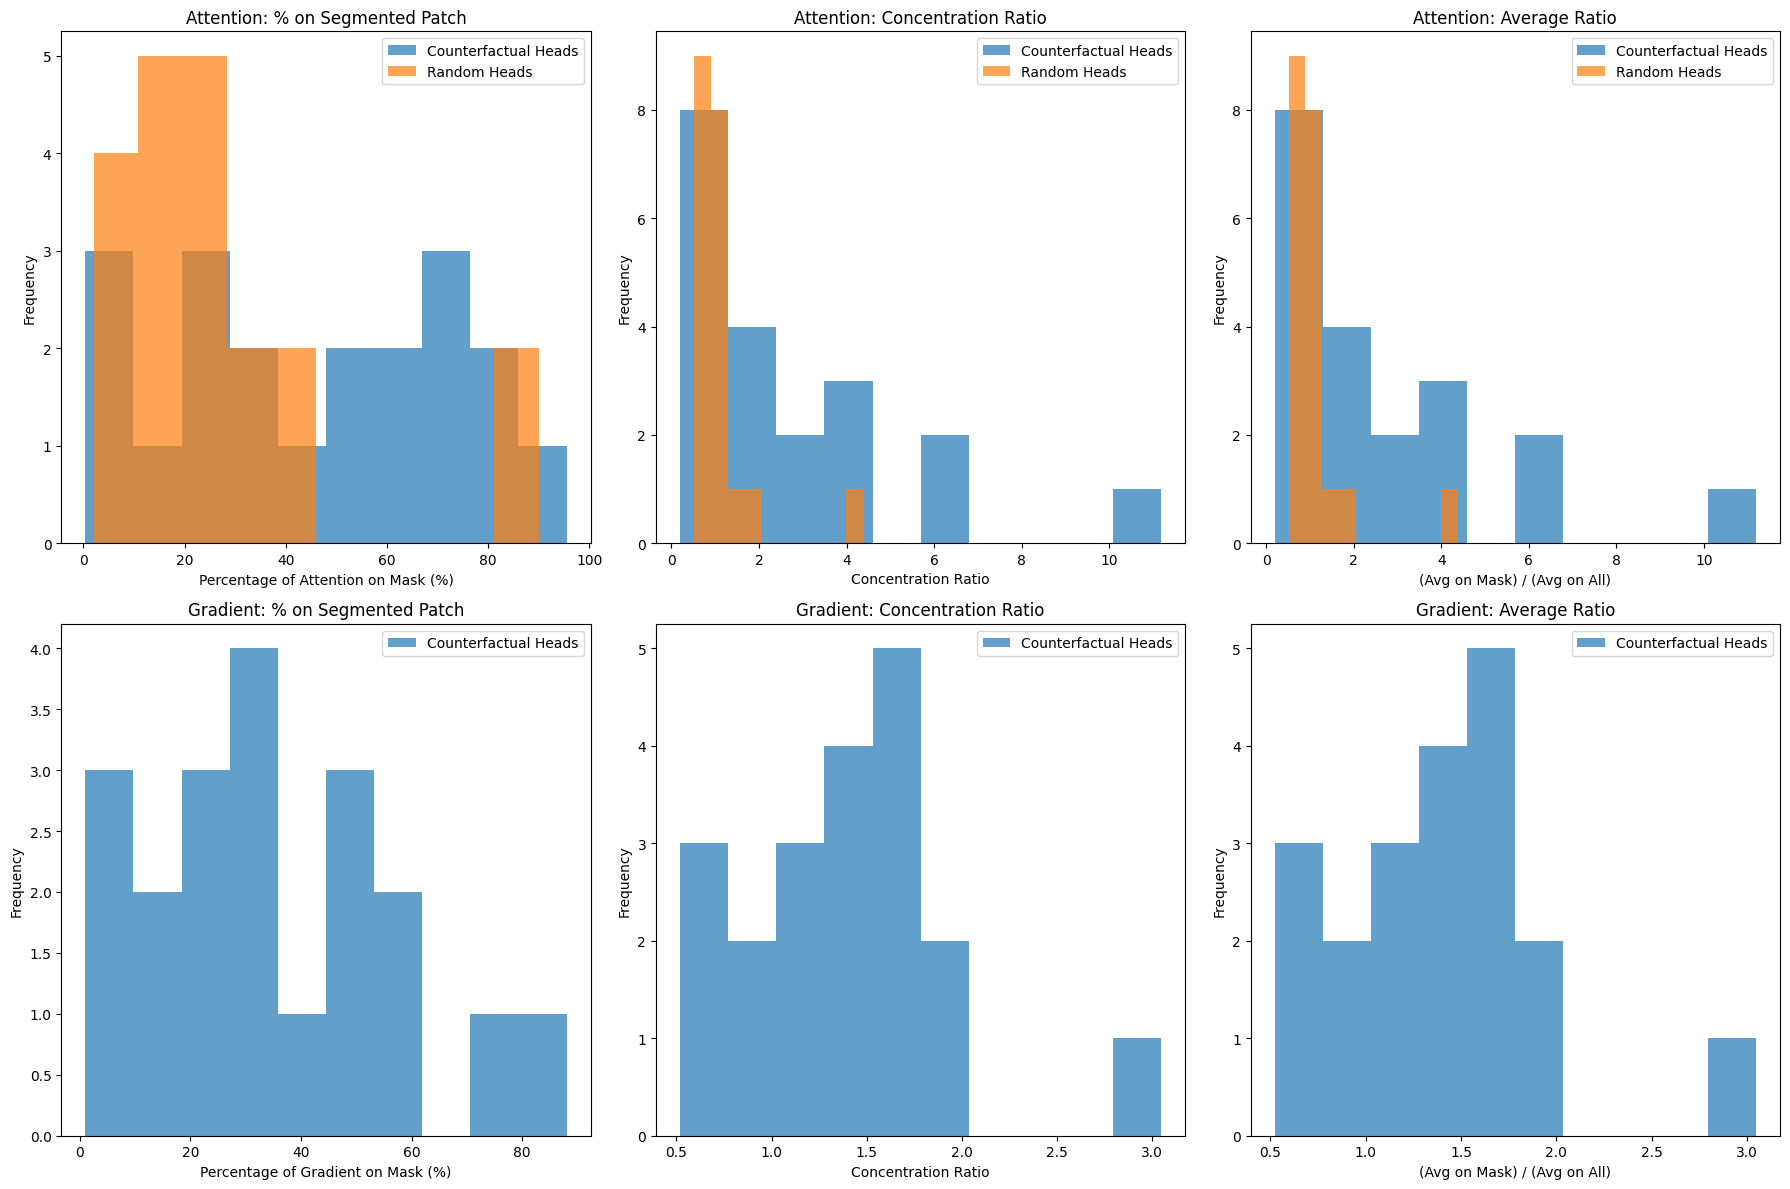

ATTENTION ANALYSIS
Mann-Whitney U Test Results:
  Percentage on Mask: U-statistic = 285.5, p-value = 2.1484e-02
  Concentration Ratio: U-statistic = 295.5, p-value = 1.0163e-02
  Average Ratio: U-statistic = 295.0, p-value = 1.0559e-02

Percentage of Attention on Segmented Patch (n=20):
  Counterfactual Heads: median 48.75% (Q1 26.06%, Q3 69.62%)
  Random Heads: median 21.38% (Q1 12.73%, Q3 30.59%)
Concentration Ratio:
  Counterfactual Heads: median 1.85 (Q1 1.06, Q3 3.58)
  Random Heads: median 0.93 (Q1 0.82, Q3 1.11)
Average Ratio (Avg on Mask / Avg on All):
  Counterfactual Heads: median 1.85 (Q1 1.06, Q3 3.60)
  Random Heads: median 0.93 (Q1 0.82, Q3 1.11)

GRADIENT ANALYSIS (w.r.t. Counterfactual Token)
Percentage of Gradient on Segmented Patch (n=20):
  Counterfactual Heads: median 29.94% (Q1 17.73%, Q3 49.12%)
Concentration Ratio:
  Counterfactual Heads: median 1.39 (Q1 1.05, Q3 1.77)
Average Ratio (Avg on Mask / Avg on All):
  Counterfactual Heads: median 1.39 (Q1 1.05, Q3 1.77

In [34]:
get_avg_measure(False)